In [85]:
import torch
import torchvision
import torch.nn as nn

import numpy as np
from einops.layers.torch import Rearrange

import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import json

from collections import Counter 

import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune import Checkpoint, ExperimentAnalysis
import tempfile

import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
TRAIN = False

# Homework description
 
In this homework, you have to build an image classification model that treats each image as a sequence of sub-images. Very similar to the recent architecture of [Visual Transformer](https://arxiv.org/pdf/2010.11929.pdf). 

In [87]:
dataset = torchvision.datasets.Caltech101('data/')

def split_caltech101(dataset_path, output_path, train_ratio=0.7, val_ratio=0.15, random_state=42):
    if not os.path.exists(output_path):
        os.makedirs(output_path, exist_ok=True)

    dataset_path, output_path = Path(dataset_path), Path(output_path)
    
    for category in [d for d in dataset_path.iterdir() if d.is_dir()]:
        if category.name == 'BACKGROUND_Google':
            continue
        images = list(category.glob('*.[jJ][pP][gG]')) + list(category.glob('*.[jJ][pP][eE][gG]'))
        if not images: continue
        
        train, temp = train_test_split(images, train_size=train_ratio, random_state=random_state)
        val, test = train_test_split(temp, train_size=val_ratio/(1-train_ratio), random_state=random_state)
        
        for split, imgs in [('train', train), ('val', val), ('test', test)]:
            dest = output_path / split / category.name.lower()
            dest.mkdir(parents=True, exist_ok=True)
            for img in imgs: shutil.copy2(img, dest / img.name)

split_caltech101(dataset_path='data/caltech101/101_ObjectCategories', output_path='data/caltech101_splitted')

In [88]:
data_dir = os.path.abspath('data/caltech101_splitted')

In [89]:
def load_data(config, data_dir, train_transform, test_transform):
    train_dataset = torchvision.datasets.ImageFolder(f'{data_dir}/train', transform=train_transform)
    valid_dataset = torchvision.datasets.ImageFolder(f'{data_dir}/val', transform=test_transform)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, 
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, 
        batch_size=config['batch_size'],
        shuffle=False, 
        num_workers=4,
        pin_memory=True
    )

    targets = [label for _, label in train_dataset]
    class_counts = Counter(targets)
    num_classes = len(class_counts)

    total_samples = len(targets)

    weights = torch.zeros(num_classes)
    for class_idx, count in class_counts.items():
        weights[class_idx] = total_samples / (num_classes * count)

    return train_loader, valid_loader, weights

In [90]:
classes = list(os.listdir(f"{data_dir}/train"))

In [91]:
# You can check how PatchEmbeddings class splits the image into patches using the image_to_patches function

class PatchEmbeddings(torch.nn.Module):
    def __init__(self, patch_size, d_model, channels=3):
        """ Patch Embedding class. 
                Takes image as an input, splits it into a number of patches of the pre-determined size (patch_size) 
                and applies a linear transformation to convert the patch into a vector representation.

            Arguments: 
                patch_size: int
                    size of the patch to cut from an image
                d_model: int
                    linear representation size of the patch
                channels: int
                    number of channels in the input image
        """
        super().__init__()
        self.patch_size = patch_size
        self.channels = channels
        self.d_model = d_model
        self.patch_dim = channels * patch_size * patch_size

        self.patch_embeddings = Rearrange(
            'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
            p1=patch_size, p2=patch_size
        )
        self.embedding = nn.Linear(
            in_features=self.patch_dim,
            out_features=d_model
        )

    def image_to_patches(self, img, plot_figure=False):
        """ Split image into patches """
        x = img.unsqueeze(0)
        x = self.patch_embeddings(x)
        batch_size, number_of_channels, _ = x.shape
        x = x.reshape(
            batch_size, number_of_channels, self.patch_size, self.patch_size, self.channels
        ).squeeze(0)

        if not plot_figure:
            return x

        fig = plt.figure(figsize=(8, 8))
        matrix_shape = np.sqrt(number_of_channels).astype(int)

        for i in range(number_of_channels):
            patch = x[i]
            ax = fig.add_subplot(matrix_shape, matrix_shape, i + 1)
            ax.axes.get_xaxis().set_visible(False)
            ax.axes.get_yaxis().set_visible(False)
            ax.imshow(patch)

    def forward(self, x):
        x = self.patch_embeddings(x)
        x = self.embedding(x)
        return x

In [92]:
# Refer to these links for more information about positional encoding 
# [1] https://kazemnejad.com/blog/transformer_architecture_positional_encoding/
# [2] https://machinelearningmastery.com/a-gentle-introduction-to-positional-encoding-in-transformer-models-part-1/ (code from here most likely won't work in out setting)
# [3] https://towardsdatascience.com/master-positional-encoding-part-i-63c05d90a0c3

class PositionalEncoding(torch.nn.Module):
    def __init__(self, d_model: int, max_seq_len: int = 256, dropout: float = 0.1):
        """
          Positional encoding class, that gives the model a notion of a position of a given patch representation
          Args:
            d_model: int 
              Embedding dims of the model 
            max_seq_len: int 
              maximum length
            dropout: float
              dropout rate
        """
        super().__init__()
        
        positions = torch.arange(0, max_seq_len).unsqueeze(1)
        div_factor = 10000 ** (torch.arange(0, d_model, 2) / d_model)

        positional_encoding = torch.zeros(max_seq_len, d_model)

        positional_encoding[:, 0::2] = torch.sin(positions / div_factor)
        positional_encoding[:, 1::2] = torch.cos(positions / div_factor)

        self.register_buffer('positional_encoding', positional_encoding)

        self.dropout = nn.Dropout(p=dropout)

    def visualize_positional_encoding(self):
        plt.figure(figsize=(8, 6))
        plt.imshow(self.positional_encoding, cmap='hot', interpolation='nearest')
        plt.show()

    def forward(self, x):
        """
        Args: 
            x: Tensor, shape [batch_size, seq_len, embedding_dim]
        """
        x = x + self.positional_encoding[:x.shape[1]]
        return self.dropout(x)


In [93]:
# Useful links
# [1] https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-recurrent-neural-networks
# [2] https://codeburst.io/recurrent-neural-network-4ca9fd4f242

class RNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.W_xh = nn.Linear(input_dim, hidden_dim)
        self.W_hh = nn.Linear(hidden_dim, hidden_dim)
        self.b = nn.Parameter(torch.randn(hidden_dim))

    def step_forward(self, x, state):
        next_state = torch.tanh(self.W_xh(x) + self.W_hh(state) + self.b)
        return next_state

    def forward(self, inputs, state=None):
        b, t, _ = inputs.shape

        if state is None:
            state = torch.zeros(b, self.hidden_dim, device=inputs.device)

        outputs = torch.zeros((b, t, self.hidden_dim), device=inputs.device)

        for idx in range(t):
            state = self.step_forward(inputs[:, idx, :], state)
            outputs[:, idx, :] = state

        return outputs, state

In [94]:
class Linear(nn.Module):
    def __init__(self, in_features, out_features, add_bias=True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.add_bias = add_bias

        self.W = nn.Parameter(torch.randn(in_features, out_features))
        self.b = nn.Parameter(torch.randn(out_features)) if add_bias else None

    def forward(self, x):
        x = x @ self.W
        if self.add_bias and self.b is not None:
            x = x + self.b
        return x

In [95]:
# Define your model here. 
# Initialize the RNN layer with hidden state dimension size 
# Initialize linear classification head. Make sure your output size matches the number of classes in the dataset

class MyModel(nn.Module):
    def __init__(self, patch_size, embedding_dim, recurrent_module: nn.Module, class_number: int, num_layers: int = 1, hidden_size: int = None, image_size: int = 224):
        super().__init__()
        
        self.num_layers = num_layers
        self.hidden_size = hidden_size if hidden_size is not None else embedding_dim
        
        num_patches = (image_size // patch_size) ** 2

        self.patch_embedding = PatchEmbeddings(
            patch_size=patch_size, d_model=embedding_dim
        )
        self.positional_encoding = PositionalEncoding(d_model=embedding_dim, max_seq_len=num_patches)
        
        self.rnn = recurrent_module(
            input_size=embedding_dim,
            hidden_size=self.hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1 if num_layers > 1 else 0
        )
        
        self.classifier = nn.Linear(self.hidden_size, class_number)

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.positional_encoding(x)

        x, _ = self.rnn(x)
        
        logits = self.classifier(x[:, -1, :])

        return logits

In [96]:
recurrent_modules = {
    "RNN": nn.RNN,
    "GRU": nn.GRU,
    "LSTM": nn.LSTM
}

# Train loops and evaluation

Here you will need to implement training and evaluation methods, as in the previous homework

1) Define methods train, evaluation, and train_epoch

2) Define your model instance, loss function, optimizer, and metric function

3) Train model

4) Evaluate model

5) Do a small hyperparameter search and visualize your results

In [97]:
from sklearn.metrics import f1_score

def train_epoch(model: nn.Module, train_loader: torch.utils.data.DataLoader, criterion: nn.Module, optimizer: torch.optim.Optimizer, device: torch.device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    for data, target in train_loader:
        data = data.float().to(device)
        target = target.long().to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
        total += target.size(0)
        
        all_preds.extend(pred.cpu().numpy())
        all_targets.extend(target.cpu().numpy())
    
    f1 = f1_score(all_targets, all_preds, average='weighted')
    return total_loss / len(train_loader), 100. * correct / total, f1

def valid_epoch(model: nn.Module, valid_loader: torch.utils.data.DataLoader, criterion: nn.Module, device: torch.device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in valid_loader:
            data = data.float().to(device)
            target = target.long().to(device)

            output = model(data)
            loss = criterion(output, target)
            
            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)
            
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    f1 = f1_score(all_targets, all_preds, average='weighted')
    return total_loss / len(valid_loader), 100. * correct / total, f1

def evaluate(model: nn.Module, device: torch.device, classes: dict):
    test_transform = torchvision.transforms.Compose(
        [   
            torchvision.transforms.Resize((224, 224)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    test_dataset = torchvision.datasets.ImageFolder(f'{data_dir}/test', transform=test_transform)

    test_loader = torch.utils.data.DataLoader(
        test_dataset, 
        batch_size=32,
        shuffle=False, 
        num_workers=4,
        pin_memory=True
    )

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
            data = data.float().to(device)
            target = target.long().to(device)

            output = model(data)

            pred = output.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    accuracy = (all_preds == all_targets).mean()
    precision_weighted = precision_score(all_targets, all_preds, average='weighted', zero_division=0)
    recall_weighted = recall_score(all_targets, all_preds, average='weighted', zero_division=0)
    f1_weighted = f1_score(all_targets, all_preds, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(all_targets, all_preds)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision_weighted:.4f}")
    print(f"Recall:    {recall_weighted:.4f}")
    print(f"F1-Score:  {f1_weighted:.4f}")

    # classes = [name for name, idx in sorted(class_dict.items(), key=lambda x: x[1])]
        
    plt.figure(figsize=(10, 8))
    plt.imshow(conf_matrix, cmap='Blues', aspect='auto')
    plt.colorbar(label='Count')
    plt.xticks(range(len(classes)), classes, rotation=45, ha='right')
    plt.yticks(range(len(classes)), classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()


def plot_best_trial_metrics(experiment_path):
    df = pd.read_csv(experiment_path)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(df['training_iteration'], df['train_loss'], marker='o', label='Train Loss')
    axes[0].plot(df['training_iteration'], df['loss'], marker='o', label='Val Loss')
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(df['training_iteration'], df['train_accuracy'], marker='o', label='Train Accuracy')
    axes[1].plot(df['training_iteration'], df['accuracy'], marker='o', label='Val Accuracy')
    axes[1].set_xlabel('Iteration', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(df['training_iteration'], df['train_f1'], marker='o', label='Train F1')
    axes[2].plot(df['training_iteration'], df['f1'], marker='o', label='Val F1')
    axes[2].set_xlabel('Iteration', fontsize=12)
    axes[2].set_ylabel('F1 Score', fontsize=12)
    axes[2].set_title('F1 Score', fontsize=14, fontweight='bold')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [98]:
def train_image_rnn(config, data_dir):
    train_transform = torchvision.transforms.Compose(
        [   
            torchvision.transforms.RandomHorizontalFlip(p=0.5),
            # torchvision.transforms.GaussianBlur(kernel_size=(5, 5), sigma=(5, 11)),
            # torchvision.transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            torchvision.transforms.RandomRotation(15),
            torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            # torchvision.transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            torchvision.transforms.Resize((224, 224)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]
    )

    test_transform = torchvision.transforms.Compose(
        [   
            torchvision.transforms.Resize((224, 224)),
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

    train_loader, valid_loader, weights = load_data(config, data_dir, train_transform, test_transform)

    recurrent_module = recurrent_modules[config['recurrent_module']]

    model = MyModel(
        patch_size=config['patch_size'],
        embedding_dim=config['embedding_dim'],
        recurrent_module=recurrent_module,
        class_number=101,
        num_layers=config['num_layers'],
        hidden_size=config['hidden_size'],
        image_size=224
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    epochs = config.get('epochs', 50)

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc, valid_f1 = valid_epoch(model, valid_loader, criterion, device)

        scheduler.step(valid_loss)

        with tempfile.TemporaryDirectory() as temp_checkpoint_dir:
            checkpoint_path = os.path.join(temp_checkpoint_dir, "checkpoint.pth")
            torch.save(model.state_dict(), checkpoint_path)
            
            tune.report(
                {"loss": valid_loss, "accuracy": valid_acc, "f1": valid_f1, "train_loss": train_loss, "train_accuracy": train_acc, "train_f1": train_f1},
                checkpoint=Checkpoint.from_directory(temp_checkpoint_dir)
            )

cfg_image_rnn = {
    "lr": tune.loguniform(1e-4, 1e-2),
    "weight_decay": tune.loguniform(1e-6, 1e-2),
    "batch_size": tune.choice([64]),
    "patch_size": tune.choice([32, 56]),
    "embedding_dim": tune.choice([128, 256, 512]),
    "recurrent_module": tune.choice(["RNN", "GRU", "LSTM"]),
    "num_layers": tune.choice([1, 2, 3, 4, 5]),
    "hidden_size": tune.choice([128, 256, 512])
}

In [99]:
if TRAIN: 
    scheduler = ASHAScheduler(
        metric="loss",
        mode="min",
        max_t=25,
        grace_period=5,
        reduction_factor=2
    )

    trainable_with_params = tune.with_parameters(train_image_rnn, data_dir=data_dir)

    tuner = tune.Tuner(
        tune.with_resources(
            trainable_with_params,
            resources={"cpu": 4, "gpu": 0.5}
        ),
        param_space=cfg_image_rnn,
        tune_config=tune.TuneConfig(
            scheduler=scheduler,
            num_samples=20
        )
    )

    results = tuner.fit()

    best_result = results.get_best_result(metric="loss", mode="min")
    print(f"\nBest trial config: {best_result.config}")
    print(f"Best trial final validation accuracy: {best_result.metrics['accuracy']:.2f}%")
    print(f"Best trial final validation loss: {best_result.metrics['loss']:.4f}")

In [100]:
checkpoint_dir = '/teamspace/studios/this_studio/ray_results/train_image_rnn_2025-11-24_16-03-01/train_image_rnn_15fab_00016_16_batch_size=64,embedding_dim=256,hidden_size=512,lr=0.0001,num_layers=5,patch_size=56,recurrent_modu_2025-11-24_16-03-16'

try:
    best_result = results.get_best_result(metric="loss", mode="min")
    best_checkpoint = best_result.checkpoint
    with best_checkpoint.as_directory() as checkpoint_dir_path:
        checkpoint_path = os.path.join(checkpoint_dir_path, "checkpoint.pth")
        checkpoint_dir = "/".join(checkpoint_dir_path.split("/")[:-1])
except NameError:
    checkpoint_files = [f for f in os.listdir(checkpoint_dir) if f.startswith('checkpoint_')]
    if checkpoint_files:
        latest_checkpoint = sorted(checkpoint_files)[-1]
        checkpoint_path = os.path.join(checkpoint_dir, latest_checkpoint, "checkpoint.pth")
    else:
        checkpoint_path = os.path.join(checkpoint_dir, "checkpoint.pth")


with open(f'{checkpoint_dir}/params.json', 'r') as f:
    params = json.load(f)
    del params['batch_size']
    del params['lr']
    del params['weight_decay']
    params['recurrent_module'] = recurrent_modules[params['recurrent_module']]

In [101]:
checkpoint_dir

'/teamspace/studios/this_studio/ray_results/train_image_rnn_2025-11-24_16-03-01/train_image_rnn_15fab_00016_16_batch_size=64,embedding_dim=256,hidden_size=512,lr=0.0001,num_layers=5,patch_size=56,recurrent_modu_2025-11-24_16-03-16'

In [102]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyModel(class_number=101, **params)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)

MyModel(
  (patch_embedding): PatchEmbeddings(
    (patch_embeddings): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=56, p2=56)
    (embedding): Linear(in_features=9408, out_features=256, bias=True)
  )
  (positional_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (rnn): RNN(256, 512, num_layers=5, batch_first=True, dropout=0.1)
  (classifier): Linear(in_features=512, out_features=101, bias=True)
)

Accuracy:  0.3871
Precision: 0.4136
Recall:    0.3871
F1-Score:  0.3816


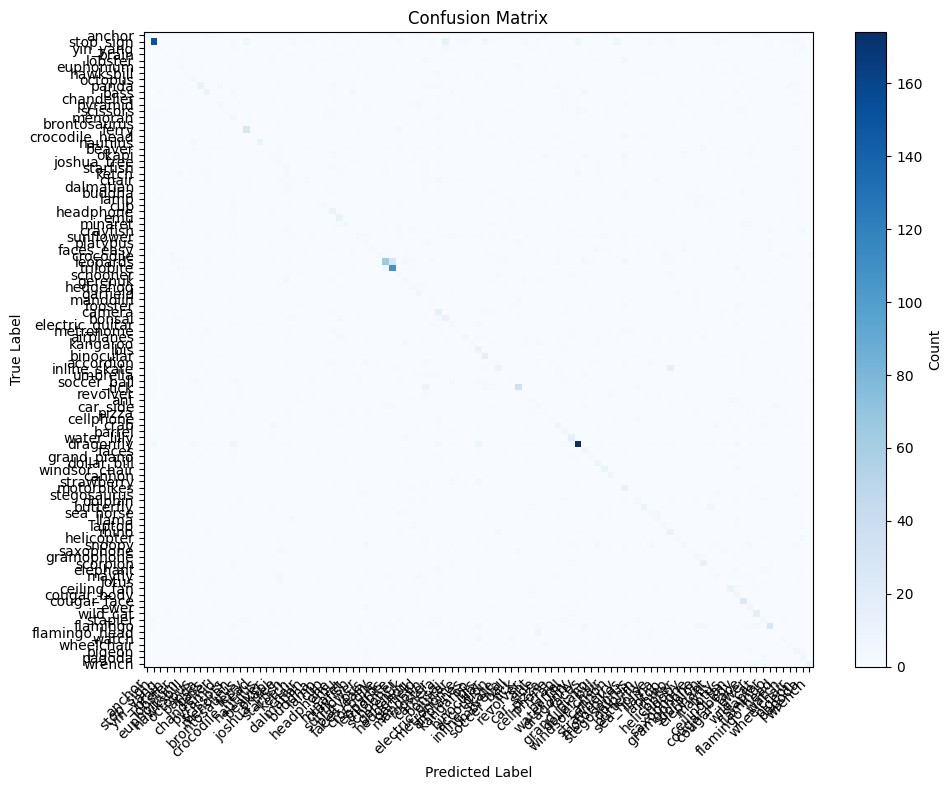

In [103]:
evaluate(model=model, device=device, classes=classes)

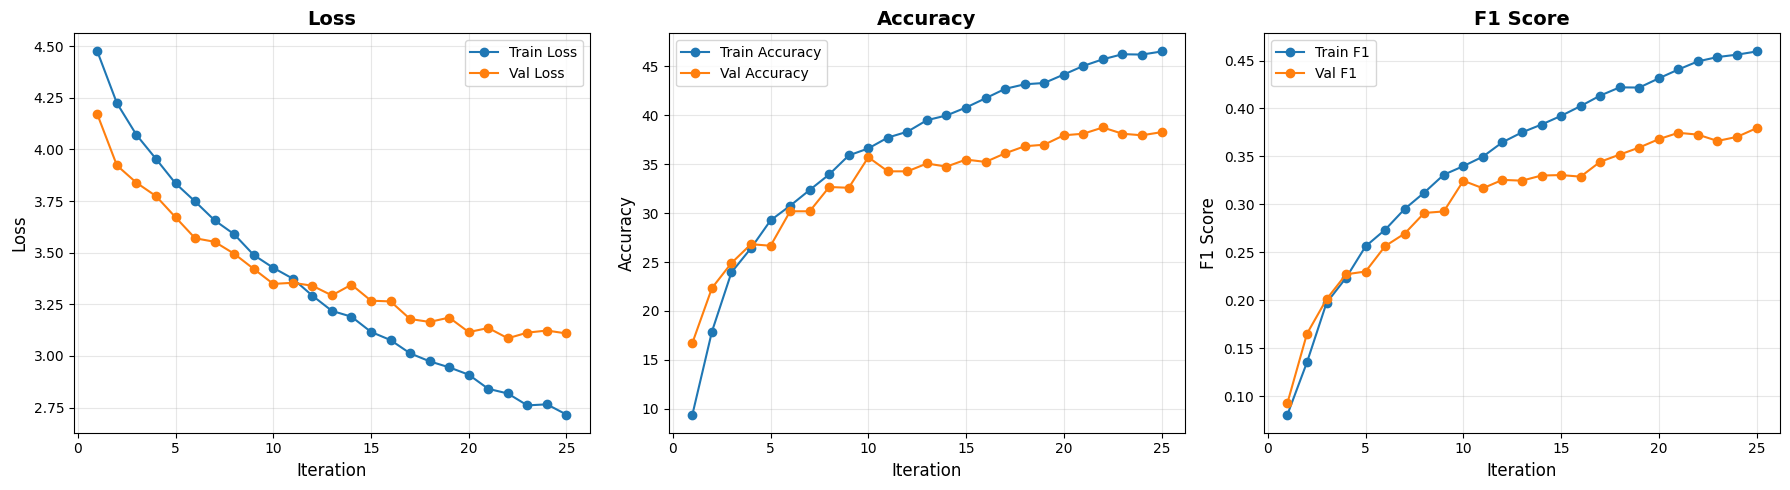

In [104]:
plot_best_trial_metrics(
    f"{checkpoint_dir}/progress.csv"
)

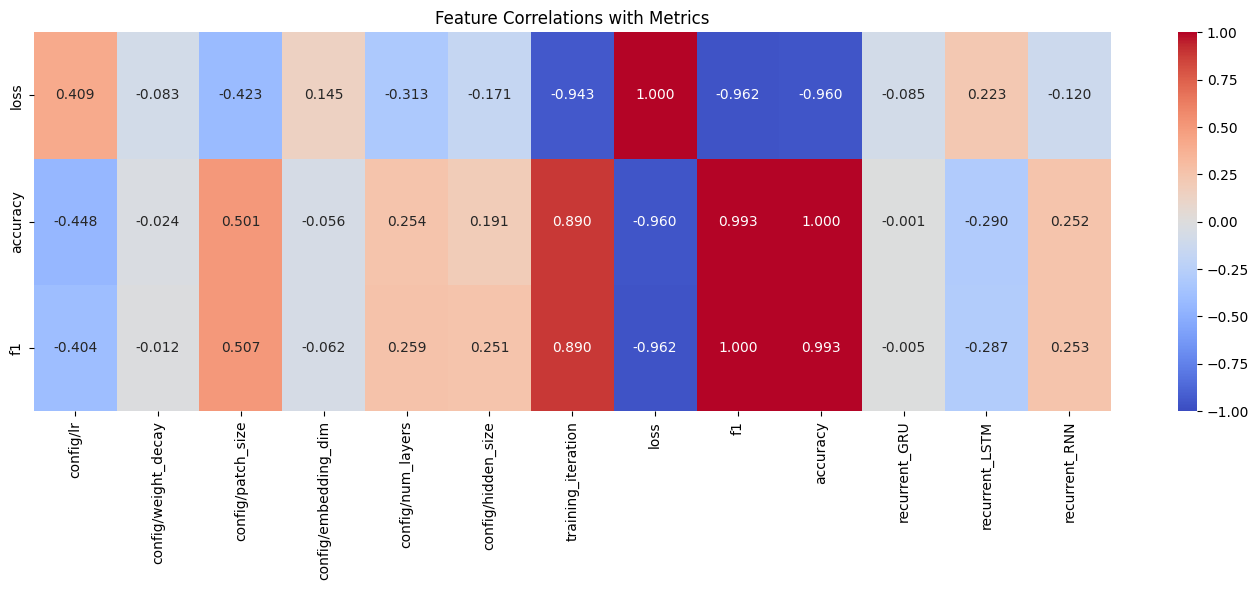

In [110]:
analysis = ExperimentAnalysis("/".join(checkpoint_dir.split("/")[:-1]))

results_df = analysis.dataframe()

param_cols = ['config/lr', 'config/weight_decay', 'config/patch_size', 'config/embedding_dim',
       'config/recurrent_module', 'config/num_layers', 'config/hidden_size', 'training_iteration']

results_clean = results_df[param_cols + ['loss', 'f1', 'accuracy']].dropna()

recurrent_dummies = pd.get_dummies(results_clean['config/recurrent_module'], prefix='recurrent')
results_clean = pd.concat([results_clean.drop('config/recurrent_module', axis=1), recurrent_dummies], axis=1)

corr_matrix = results_clean.corr()

metrics_corr = corr_matrix[['loss', 'accuracy', 'f1']].T

plt.figure(figsize=(14, 6))
sns.heatmap(metrics_corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Feature Correlations with Metrics')
plt.tight_layout()
plt.show()

# Conclusion

RNNs cope with image classification by treating images as sequences of patches (56×56 patches with 256-dim embeddings), processing them sequentially through 5-layer RNN with 512-dim hidden states, achieving 38.71% accuracy on Caltech-101. The best hyperparameters were vanilla RNN with 5 layers, 512 hidden size, 256 embedding dimension, 56×56 patch size, and 0.0001 learning rate. 

However, RNNs are fundamentally limited for vision tasks compared to CNNs and ViTs: they lack 2D spatial inductive bias, process patches sequentially (no parallelization), suffer from vanishing gradients across sequences, and achieve significantly lower accuracy (<40%) versus CNNs (>90%) and ViTs (>95%) on the same dataset. The sequential processing bottleneck and inability to capture hierarchical spatial features make RNNs bad for image classification